![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# Part 1: Text Analysis


For each of the hotels extract the text on the description (and possibly other text
metadata) and do the following:

1. Pre-process the text by removing stop words and stemming. Customize your
stopword list if needed.
2. Create two wordclouds before and after pre-processing for each city (a total of
four). Comment on the changes in the wordclouds.


**Chosen event**: Mobile World Congress (3rd to 6th March in 2025).

## 0. Packages

In [435]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: C:\Users\adral\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [436]:
import re
import nltk
import spacy
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


from nltk.stem import PorterStemmer
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Download NLTK data (if needed)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

## 1. File Load

We are going to two main files:

**General Results:** A collection of files following the format `results_YYYY-MM-DD&YYYY-MM-DD_City.csv`, where:

`YYYY-MM-DD` represents the start and end dates of the dataset.
City indicates the location for which the data was collected.

Information of city and dates are included in the dataset as new fields.

**Hotel Descriptions File:** The file `descriptions_5452.csv` contains scraped text descriptions for each hotel. This dataset serves as the primary text source for our analysis.

In [437]:
import pandas as pd
import re
import os

# Define the path where the CSV files are located
csv_directory = os.path.join(os.getcwd(), "files", "general_results")

def extract_date_city(file_name):
    """Extracts start date, end date, and city from the file name."""
    match = re.search(r"results_(\d{4}-\d{2}-\d{2})&(\d{4}-\d{2}-\d{2})_(.+)\.csv", file_name)
    if match:
        start_date, end_date, city = match.groups()
        return start_date, end_date, city.replace("_", " ")
    return None, None, None

# Get all CSV files that start with 'results' in the specified directory
csv_files = [f for f in os.listdir(csv_directory) if f.startswith('results') and f.endswith('.csv')]

# Create an empty list to store DataFrames
df_list = []

for file_name in csv_files:
    file_path = os.path.join(csv_directory, file_name)
    
    # Load the file into a DataFrame
    df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)
    
    # Extract date and city information
    start_date, end_date, city = extract_date_city(file_name)
    
    # Add new columns to the DataFrame
    df['start_date'] = start_date
    df['end_date'] = end_date
    df['city'] = city
    
    # Ensure the start_date and end_date columns are in datetime format
    df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
    df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')
    
    # Append to the list of DataFrames
    df_list.append(df)

# Concatenate all DataFrames into one
df_combined = pd.concat(df_list, ignore_index=True)
df_combined.head()

,hotel_name,price_euros,rating,num_reviews,quality_over_5,quality_type,neighborhood,description,start_date,end_date,city
0,Be Mate Paseo de Gracia,2517.0,8.9,1206.0,4.0,squares,"Gràcia, Barcelona",Penthouse Apartment\r\nEntire apartment • 2 be...,2025-02-01,2025-02-08,Barcelona
1,Tembo Barcelona,2598.0,8.8,2660.0,4.0,stars,Barcelona,One-Bedroom Premium Apartment\r\nEntire apartm...,2025-02-01,2025-02-08,Barcelona
2,Unite Hostel Barcelona,1079.0,8.0,8415.0,NaN,NaN,"Sant Martí, Barcelona",Family Room with Private Bathroom\r\n8 bunk beds,2025-02-01,2025-02-08,Barcelona
3,Catalonia Sagrada Familia,1207.0,8.4,9406.0,3.0,stars,"Sant Martí, Barcelona",Double or Twin Room\r\nBeds: 1 double or 2 twi...,2025-02-01,2025-02-08,Barcelona
4,NH Collection Barcelona Gran Hotel Calderon,2178.0,8.2,2920.0,5.0,stars,"Eixample, Barcelona",Superior Double or Twin Room\r\nBeds: 1 double...,2025-02-01,2025-02-08,Barcelona


We filter the hotel data for two specific weeks: February 9th to 16th and March 1st to 8th, covering both Madrid and Barcelona.

Then, we filter the data to keep only the hotels that appear in both time periods for each city. This way, we focus on hotels that have consistent availability, making our analysis more reliable.

In [438]:
# Define the specific periods for filtering
first_period = (pd.to_datetime("2025-02-09"), pd.to_datetime("2025-02-16"))
second_period = (pd.to_datetime("2025-03-01"), pd.to_datetime("2025-03-08"))

# Find hotels that appear in both periods
df_first_period = df_combined[(df_combined['start_date'] == first_period[0]) & (df_combined['end_date'] == first_period[1])]
df_second_period = df_combined[(df_combined['start_date'] == second_period[0]) & (df_combined['end_date'] == second_period[1])]

# Merge both periods to get only hotels that exist in both time frames, keeping hotel_name, city, and description
df_filtered = pd.merge(df_first_period[['hotel_name', 'city', 'description', 'price_euros',	'rating',	'num_reviews',	'quality_over_5', 'quality_type']], 
                       df_second_period[['hotel_name', 'city', 'description', 'price_euros']], 
                       on=['hotel_name', 'city'], 
                       suffixes=('_first', '_second'))

# Sort the filtered DataFrame by hotel name
df_filtered = df_filtered.sort_values(by=['hotel_name'])

# Display the first rows of the sorted DataFrame
print("Filtered and Sorted Hotels in Both Periods")
df_filtered.head()


Filtered and Sorted Hotels in Both Periods


,hotel_name,city,description_first,price_euros_first,rating,num_reviews,quality_over_5,quality_type,description_second,price_euros_second
721,#10OCA6 - Apartamento en Vista Alegre,"Madrid, Community of Madrid",Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0,6.9,22.0,3.0,squares,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0
355,021 Center Barca 2 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,761.0,1.2,4.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,1819.0
334,031 Center barca 3 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,790.0,2.8,11.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,3421.0
353,042 Center Barça 4 2,Barcelona,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,761.0,2.7,7.0,NaN,NaN,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,1297.0
114,08028 Apartments,Barcelona,Twin Room - No Kitchen\r\n2 twin beds\r\nOnly ...,935.0,8.8,4274.0,4.0,squares,Studio Apartment (1 - 2 Adults)\r\nEntire apar...,1824.0


The hotel data from the general results CSV files is cross-referenced with the hotel descriptions CSV file (descriptions_5452.csv). This process ensures that each hotel in the dataset is matched with its corresponding description.

In [439]:
# Load descriptions file
descriptions_path = os.path.join(os.getcwd(), "files", "accommodation_descriptions", "descriptions_5452.csv")
df_descriptions = pd.read_csv(descriptions_path, encoding="utf-8", low_memory=False)

# Merge filtered hotels with descriptions
df_final = pd.merge(df_filtered, df_descriptions[['hotel_name', 'description']], on='hotel_name', how='left')

# Sort the final DataFrame by hotel name
df_final = df_final.sort_values(by=['hotel_name'])

# Display the first rows of the final merged DataFrame
print("Final Merged DataFrame with Descriptions")
df_final.head()

Final Merged DataFrame with Descriptions


,hotel_name,city,description_first,price_euros_first,rating,num_reviews,quality_over_5,quality_type,description_second,price_euros_second,description
0,#10OCA6 - Apartamento en Vista Alegre,"Madrid, Community of Madrid",Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0,6.9,22.0,3.0,squares,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0,Situated 5.2 km from Parque de Atracciones de ...
1,021 Center Barca 2 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,761.0,1.2,4.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,1819.0,"Situated in Barcelona, 2 km from Somorrostro B..."
2,031 Center barca 3 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,790.0,2.8,11.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,3421.0,"Set in Barcelona, 2 km from Somorrostro Beach ..."
3,042 Center Barça 4 2,Barcelona,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,761.0,2.7,7.0,NaN,NaN,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,1297.0,"Located in Barcelona, 2 km from Somorrostro Be..."
4,08028 Apartments,Barcelona,Twin Room - No Kitchen\r\n2 twin beds\r\nOnly ...,935.0,8.8,4274.0,4.0,squares,Studio Apartment (1 - 2 Adults)\r\nEntire apar...,1824.0,08028 Apartments are situated next to Les Cort...


## 2. Pre-processing

The text data is cleaned and prepared by removing stopwords, tokenizing, and applying stemming to standardize word forms. Below some functions are defined to achieve this goal.

In [440]:
# Load spaCy model
sp = spacy.load("en_core_web_sm")

# Load previous preprocessing functions
porter=SnowballStemmer("english")
lmtzr = WordNetLemmatizer()

STOP_WORDS = set(stopwords.words('spanish') + stopwords.words('english'))
"""custom_stopwords = {
    'km', 'metres', 'away', 'minutes', 'walk', 'distance', 'located', 'situated', 
    'property', 'apartment', 'hotel', 'guest', 'room', 'accommodation', 
    'feature', 'unit', 'offer', 'include', 
    'bathroom', 'private', 'available', 'air conditioning', 'shower', 
    'towels', 'bed linen', 'wifi', 'free wifi', 'bathroom', 'private', 'available', 'kitchen', 
    'tv', 'balcony'
}"""
custom_stopwords = {
    'barcelona', 'madrid', 'hotel', 'hostel', 'guest', 'room', 'accommodation',
    'km', 'metres', 'away', 'minutes', 'walk', 'distance', 'located', 'situated',
    'feature', 'unit', 'offer', 'include', 'units', 'bathroom', 'private', 
    'available', 'desk', 'bathroom', 'private', 'available', 'apartment', 'house', 'tv', 'balcony',
    'wifi', 'free wifi', 'apartments', 'popular', 'modern', 'stylish', 'service', 'access'
}
STOP_WORDS.update(custom_stopwords)


def remove_initial_paragraph(text):
    #build the expression
    pattern = re.compile(r'The Security Council\s?,')
    #test the expression
    match = pattern.search(text)
    # we basically want to use this as a splitter and remove everything before it
    if match:
        return text[match.end():]
    else:
        #might wanna print somwthing here but we've already checked it.
        return text        

def preprocess_lower(text):
    
    # Lowercase the text
    text_lower = text.lower()

    # Remove punctuation (everything except word characters and whitespace)
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)

    # Tokenize the cleaned text.
    tokens = word_tokenize(text_no_punct)

    # Filter out stopwords.
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]

    return " ".join(filtered_tokens)


def preprocess_stem(text):

    # Get the cleaned lowercased and stopwords-removed tokens.
    joined_tokens = preprocess_lower(text)
    
    tokens=word_tokenize(joined_tokens)

    # Initialize the Porter Stemmer.
    ps = PorterStemmer()

    # Stem each token.
    stemmed_tokens = [ps.stem(token) for token in tokens]

    return " ".join(stemmed_tokens)


def preprocess_lemma(text):

    # Process text using spaCy
    doc = sp(text)

    # Extract the lemma of each token, filtering out tokens flagged as punctuation or stopwords.
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']

    return " ".join(lemmatized_tokens)


def tokenize(text, mode=0):

    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")

Applying preprocessing functions to description field in dataframe.

In [441]:
# Apply preprocessing functions to the DataFrame
df_final['description_no_stopwords'] = df_final['description'].apply(lambda x: preprocess_lower(x) if pd.notna(x) else "")
df_final['description_stem'] = df_final['description_no_stopwords'].apply(lambda x: preprocess_stem(x) if pd.notna(x) else "")

df_final

,hotel_name,city,description_first,price_euros_first,rating,num_reviews,quality_over_5,quality_type,description_second,price_euros_second,description,description_no_stopwords,description_stem
0,#10OCA6 - Apartamento en Vista Alegre,"Madrid, Community of Madrid",Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0,6.9,22.0,3.0,squares,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,601.0,Situated 5.2 km from Parque de Atracciones de ...,52 parque atracciones 52 mercado san miguel 10...,52 parqu atraccion 52 mercado san miguel 10oca...
1,021 Center Barca 2 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,761.0,1.2,4.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,1819.0,"Situated in Barcelona, 2 km from Somorrostro B...",2 somorrostro beach 21 sant miquel beach 021 c...,2 somorrostro beach 21 sant miquel beach 021 c...
2,031 Center barca 3 1,Barcelona,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,790.0,2.8,11.0,NaN,NaN,Two-Bedroom Apartment\r\nEntire apartment • 2 ...,3421.0,"Set in Barcelona, 2 km from Somorrostro Beach ...",set 2 somorrostro beach 21 sant miquel beach 0...,set 2 somorrostro beach 21 sant miquel beach 0...
3,042 Center Barça 4 2,Barcelona,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,761.0,2.7,7.0,NaN,NaN,Loft\r\nEntire apartment • 2 bedrooms • 1 bath...,1297.0,"Located in Barcelona, 2 km from Somorrostro Be...",2 somorrostro beach 21 sant miquel beach 042 c...,2 somorrostro beach 21 sant miquel beach 042 c...
4,08028 Apartments,Barcelona,Twin Room - No Kitchen\r\n2 twin beds\r\nOnly ...,935.0,8.8,4274.0,4.0,squares,Studio Apartment (1 - 2 Adults)\r\nEntire apar...,1824.0,08028 Apartments are situated next to Les Cort...,08028 next corts metro station 5 barcelonas ca...,08028 next cort metro station 5 barcelona camp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,limehome Madrid La Bolsa,"Madrid, Community of Madrid",Studio Apartment with Balcony\r\nEntire studio...,1135.0,8.9,1053.0,3.0,squares,Studio Apartment with Balcony\r\nEntire studio...,1240.0,Limehome Madrid La Bolsa provides accommodatio...,limehome bolsa provides within 300 centre free...,limehom bolsa provid within 300 centr free kit...
903,min hostel capsules,"Madrid, Community of Madrid",Double Room\r\n1 full bed\r\nFree cancellation...,292.0,6.7,749.0,NaN,NaN,Double Room\r\n1 full bed\r\nFree cancellation...,292.0,Ideally located in the Ciudad Lineal district ...,ideally ciudad lineal district min capsules 56...,ideal ciudad lineal district min capsul 56 san...
904,room Select Sol,"Madrid, Community of Madrid",Economy Double Room\r\n1 full bed,824.0,8.7,6157.0,3.0,stars,Superior Double Room\r\n1 full bed\r\nOnly 5 r...,1175.0,"room Select Sol is set in Madrid, 200 metres f...",select sol set 200 plaza mayor 400 royal palac...,select sol set 200 plaza mayor 400 royal palac...
905,´Vicens Gem´ Private terrace HS Wi-Fi in Graci...,Barcelona,One-Bedroom Apartment\r\nEntire apartment • 1 ...,1197.0,9.9,33.0,4.0,squares,One-Bedroom Apartment\r\nEntire apartment • 1 ...,2356.0,´Vicens Gem´ Private terrace HS Wi-Fi in Graci...,vicens gem terrace hs gracia myrentalhost feat...,vicen gem terrac hs gracia myrentalhost featur...


### 3. World Clouds

Here, we generate word clouds for each city to visualize the most frequent words.

In [442]:
# Define a function to generate word clouds for each city
def generate_wordclouds(df, text_column):
    city_corpus = {}
    
    # Iterate through each unique city in the dataset
    for city in df['city'].unique():
        # Filter descriptions by city
        text_corpus = " ".join(df[df['city'] == city][text_column].dropna())
        
        # Store the processed text in the dictionary
        city_corpus[city] = text_corpus
    
    # Generate and display word clouds side by side
    num_cities = len(city_corpus)
    fig, axes = plt.subplots(1, num_cities, figsize=(10 * num_cities, 5))
    
    if num_cities == 1:
        axes = [axes]  # Ensure axes is iterable if there's only one city
    
    for ax, (city, text) in zip(axes, city_corpus.items()):
        if text.strip():  # Ensure the text is not empty
            wordcloud = WordCloud(
                width=800, 
                height=400, 
                background_color='white', 
                colormap='viridis', 
                max_words=100
            ).generate(text)
            
            # Display the word cloud
            ax.imshow(wordcloud, interpolation="bilinear")
            ax.axis("off")  # Remove axes
            ax.set_title(f"Word Cloud for {city}")
    
    plt.show()



### 3.1 World Cloud Before Pre-Processing

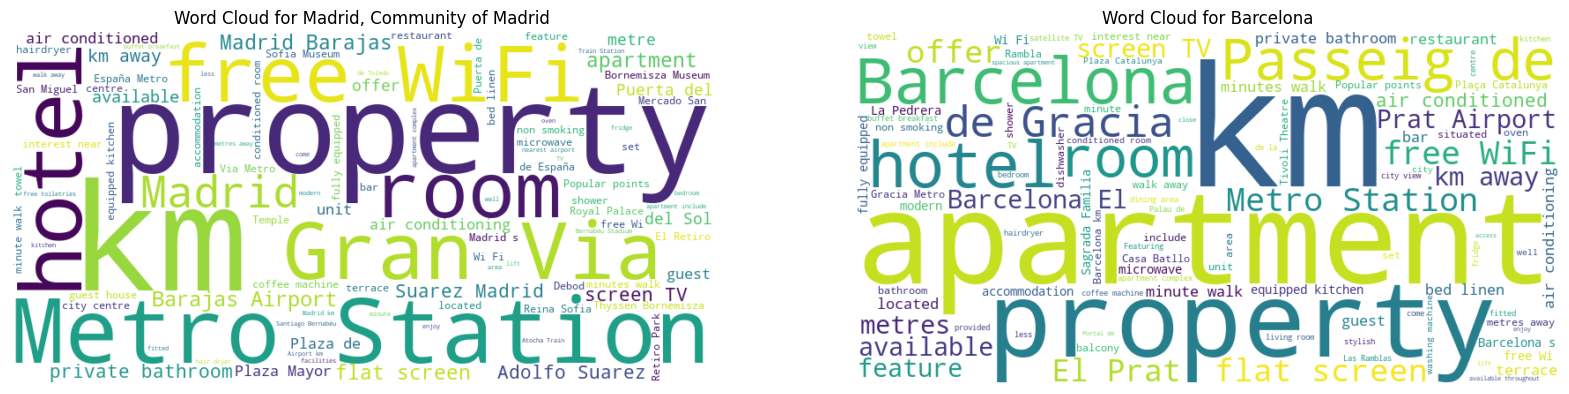

In [443]:
# Generate word clouds before pre-processing
generate_wordclouds(df_final, 'description')

### 3.2. Word clouds After Stopwords Removal

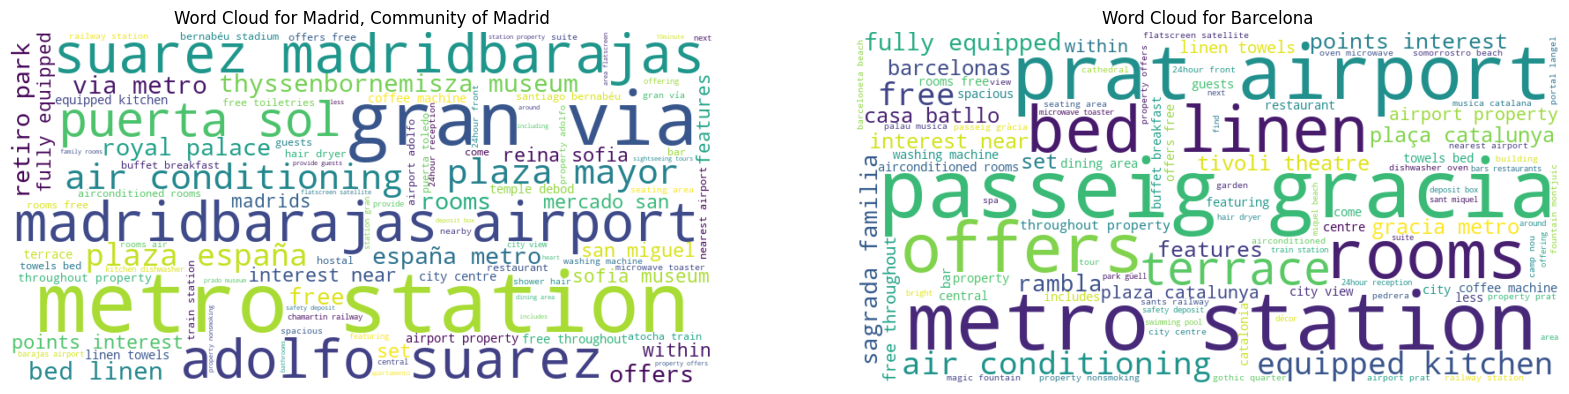

In [444]:
# Generate word clouds after stop word removal
generate_wordclouds(df_final, 'description_no_stopwords')

### 3.3. World Cloud after Stemming

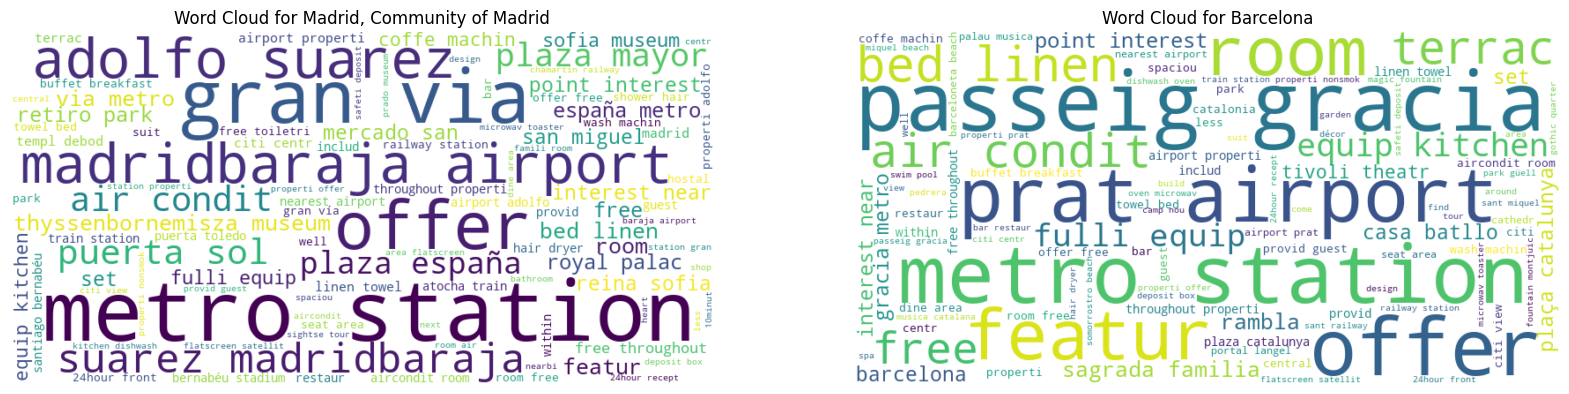

In [445]:
# Generate word clouds after stem
generate_wordclouds(df_final, 'description_stem')

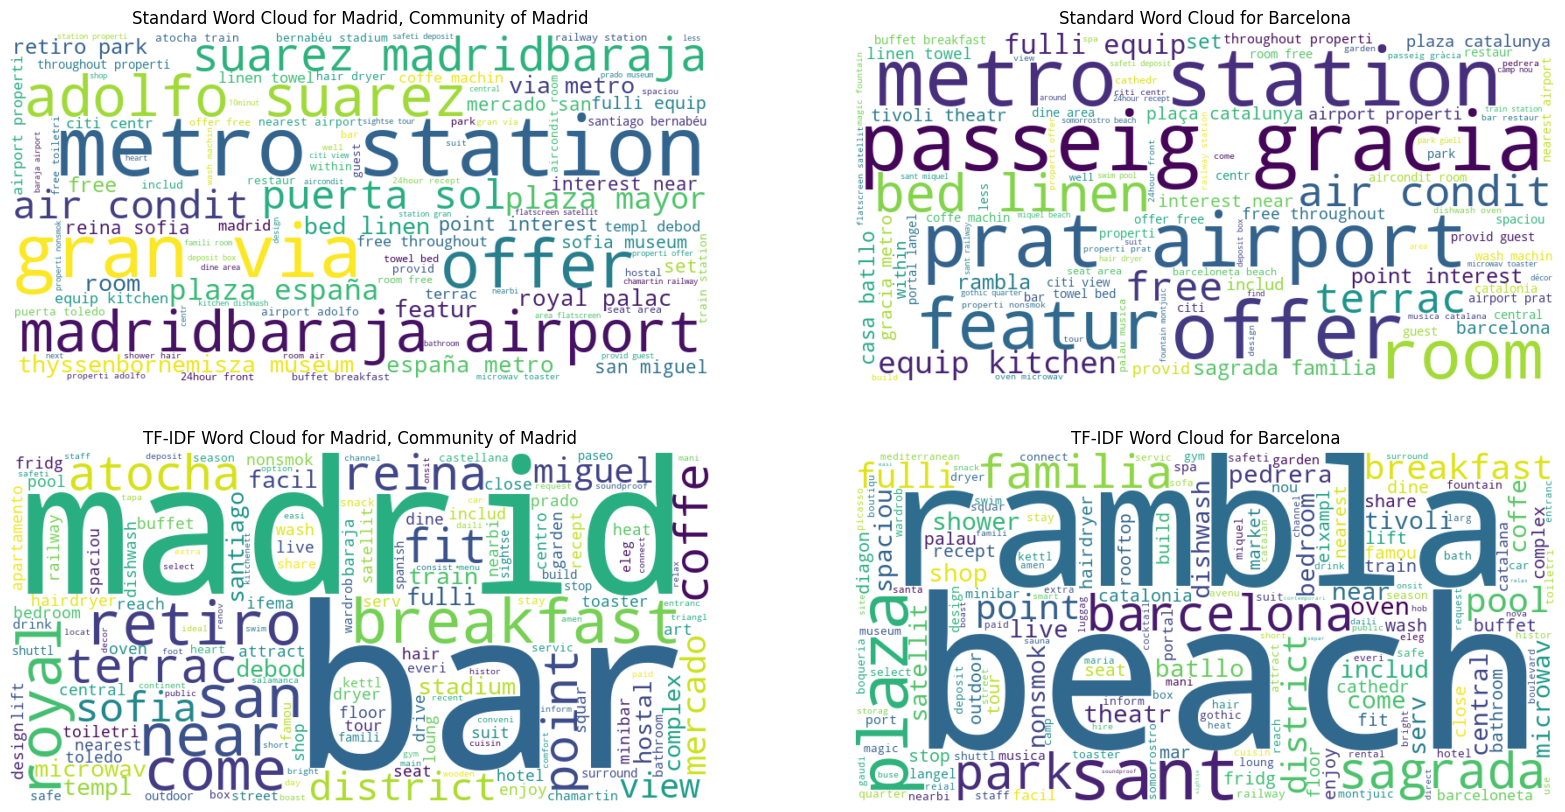

In [446]:
def generate_wordclouds(df, text_column, title):
    city_corpus = {}
    
    # Iterate through each unique city in the dataset
    for city in df['city'].unique():
        # Filter descriptions by city
        text_corpus = " ".join(df[df['city'] == city][text_column].dropna())
        
        # Store the processed text in the dictionary
        city_corpus[city] = text_corpus
    
    # Generate and display word clouds side by side
    num_cities = len(city_corpus)
    fig, axes = plt.subplots(2, num_cities, figsize=(10 * num_cities, 10))
    
    if num_cities == 1:
        axes = np.array([[axes], [axes]])  # Ensure axes is iterable if there's only one city
    
    for i, (city, text) in enumerate(city_corpus.items()):
        if text.strip():  # Ensure the text is not empty
            # Generate standard word cloud
            wordcloud = WordCloud(
                width=800, 
                height=400, 
                background_color='white', 
                colormap='viridis', 
                max_words=100
            ).generate(text)
            
            axes[0, i].imshow(wordcloud, interpolation="bilinear")
            axes[0, i].axis("off")
            axes[0, i].set_title(f"Standard Word Cloud for {city}")
            
            # Generate TF-IDF word cloud
            text_data = df[df['city'] == city][text_column].dropna()
            if not text_data.empty:
                cv = TfidfVectorizer(
                    norm=None, min_df=0.05, max_df=0.3, stop_words='english', 
                    token_pattern=r'\b[a-zA-Z]{3,}\b', sublinear_tf=False
                )
                
                vectorized_text = cv.fit_transform(text_data)
                vectorized_text = vectorized_text.todense()



                
                features_tfidf = cv.get_feature_names_out()
                tfidf_sum = np.asarray(vectorized_text.sum(axis=0)).ravel()
                freq_dict_tfidf = dict(zip(features_tfidf, tfidf_sum))
                
                wordcloud_tfidf = WordCloud(
                    width=800, height=400, background_color="white", colormap='viridis'
                ).generate_from_frequencies(freq_dict_tfidf)
                
                axes[1, i].imshow(wordcloud_tfidf, interpolation="bilinear")
                axes[1, i].axis("off")
                axes[1, i].set_title(f"TF-IDF Word Cloud for {city}")
    
    plt.show()

# Generate word clouds using the specified column
generate_wordclouds(df_final, 'description_stem', "Word Clouds for Cities")

**Even though "Madrid" is included as a stopword, it reappears after stemming due to variations in word forms.**



## 4. Exporting Results into a CSV File

Standard Results

In [447]:
df_final.to_csv("files/text_analysis/text_analysis_final_results.csv", index=False, encoding="utf-8")